# Observations

### PCA removes correlated features. Are correlated features tied to drifts?
I am using **PCA** to reduce the number of embedding dimensions for drift detection. Since PCA removes variance along lower-ranked components, this might impact drift detection if **correlation and drift are related**. Key considerations:

- **Evaluate performance impact**: Compare drift detection results **before and after PCA**. Does performance degrade?
- **Determine optimal components**: Use domain knowledge to retain **enough variance** to capture meaningful drift.
- **Consider alternative methods**: If PCA removes too much structure, explore techniques like **autoencoders** or **UMAP**.
- **Assess impact on statistical methods**: Tests such as **MMD (Maximum Mean Discrepancy)** or **KS-test** may behave differently with PCA.

## Time and Overhead
I need to **rerun experiments** now that I have included **time and `avg_overhead`** as variables to measure:
1. **Time taken per measurement**
2. **Compute overhead per method**

## Outliers in Metrics
During our analysis, we **spotted outliers in all metrics**, which raises the question of how to handle them:
- Are these outliers **legitimate variations**, or do they indicate **errors/noise** in the data?
- Should we **remove, adjust, or separately analyze** them?
- How do they affect **drift detection performance and overhead**?

### Key Hypothesis
- Full embedding calculation might be **computationally expensive**, but reducing dimensions may also **remove relevant information**.
- For **distribution-based approaches**, we often reduce components to **two** to create histograms. If this degrades performance, it could indicate that:
  - **Vector-based distance metrics** are **faster** and have lower overhead.
  - Or, alternatively, **histogram-based approaches** might be **more efficient** despite dimensionality reduction.
- **Next Steps:** Further testing is required to confirm these trade-offs. **T.B.C.** 🚀

### Next Steps
- Good good, we can see that an increase of drift strength leads to relative increase of all metrics
- We need to set thresholds that indicate that a drift occurs (dynamic thresholding, still hot research topic). Instead of being reliable to fixed hyperparameters that well in controlled environments we want to 


In [2]:
from sklearn.preprocessing import MinMaxScaler
from collections import defaultdict
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import os

In [3]:
df_distribution = pd.read_csv('data-analysis/data/all_results_distribution_aggregated.csv')
df_distance = pd.read_csv('data-analysis/data/all_results_vector_space.csv')

In [4]:
df_distribution.head()

,Dataset,Model,Measure,Drift Strength,Mean_Value,Std_Value
0,ag_news,bert-base-uncased,bhattacharyya,0.00,0.079181,0.006346
1,ag_news,bert-base-uncased,bhattacharyya,0.25,0.137328,0.006751
2,ag_news,bert-base-uncased,bhattacharyya,0.50,0.225418,0.018237
3,ag_news,bert-base-uncased,bhattacharyya,0.75,0.280828,0.024838
4,ag_news,bert-base-uncased,bhattacharyya,1.00,0.304277,0.017785


In [5]:
# print all unique Measure

# Group by Measure and compute relative increase and STD per measurement
df_sorted = df_distribution.sort_values(by=["Measure", "Dataset", "Model", "Drift Strength"])

# Compute the relative increase for each measurement
df_sorted["Relative Increase"] = df_sorted.groupby(["Measure", "Dataset", "Model"])["Mean_Value"].pct_change()

# Compute the standard deviation per measurement
std_per_measurement = df_sorted.groupby("Measure")["Std_Value"].mean()

# Compute the relative increase per measurement (average across datasets/models)
relative_increase_per_measurement = df_sorted.groupby("Measure")["Relative Increase"].mean()

# Combine results
results = pd.DataFrame({
    "Relative Increase": relative_increase_per_measurement,
    "STD": std_per_measurement
}).reset_index()

# Apply log transformation to Relative Increase and STD
log_transformed = np.log1p(results[["Relative Increase", "STD"]])

# Apply Min-Max scaling
min_max_scaler = MinMaxScaler()
scaled_log_values = min_max_scaler.fit_transform(log_transformed)

# Create a new DataFrame with the transformed values
scaled_log_results = results.copy()
scaled_log_results[["Log-Scaled Relative Increase", "Log-Scaled STD"]] = scaled_log_values

# Order the dataframe by Log-Scaled Relative Increase in descending order
ordered_scaled_log_results = scaled_log_results.sort_values(by="Log-Scaled Relative Increase", ascending=False)

ordered_scaled_log_results = ordered_scaled_log_results.drop(columns=["Relative Increase", "STD"])

# Round the final variables to 4 decimal places
ordered_scaled_log_results[["Log-Scaled Relative Increase", "Log-Scaled STD"]] = ordered_scaled_log_results[[
    "Log-Scaled Relative Increase", "Log-Scaled STD"]].round(4)


ordered_scaled_log_results

,Measure,Log-Scaled Relative Increase,Log-Scaled STD
4,mmd,1.0000,0.0000
5,wasserstein,0.8857,0.4215
3,kl,0.6082,1.0000
0,bhattacharyya,0.4162,0.0381
2,js,0.3411,0.0175
1,hellinger,0.0000,0.0314


         Measure  Log-Scaled Relative Increase  Log-Scaled STD
4            mmd                        1.0000          0.0000
5    wasserstein                        0.8807          0.4215
3             kl                        0.5957          1.0000
0  bhattacharyya                        0.4028          0.0381
2             js                        0.3285          0.0175
1      hellinger                        0.0000          0.0314
Hellinger Data:
              Dataset                  Model  Drift Strength  Mean_Value  \
5             ag_news      bert-base-uncased            0.00    0.275749   
6             ag_news      bert-base-uncased            0.25    0.358762   
7             ag_news      bert-base-uncased            0.50    0.453901   
8             ag_news      bert-base-uncased            0.75    0.494932   
9             ag_news      bert-base-uncased            1.00    0.516249   
35            ag_news  nlpaueb/sec-bert-base            0.00    0.256815   
36         

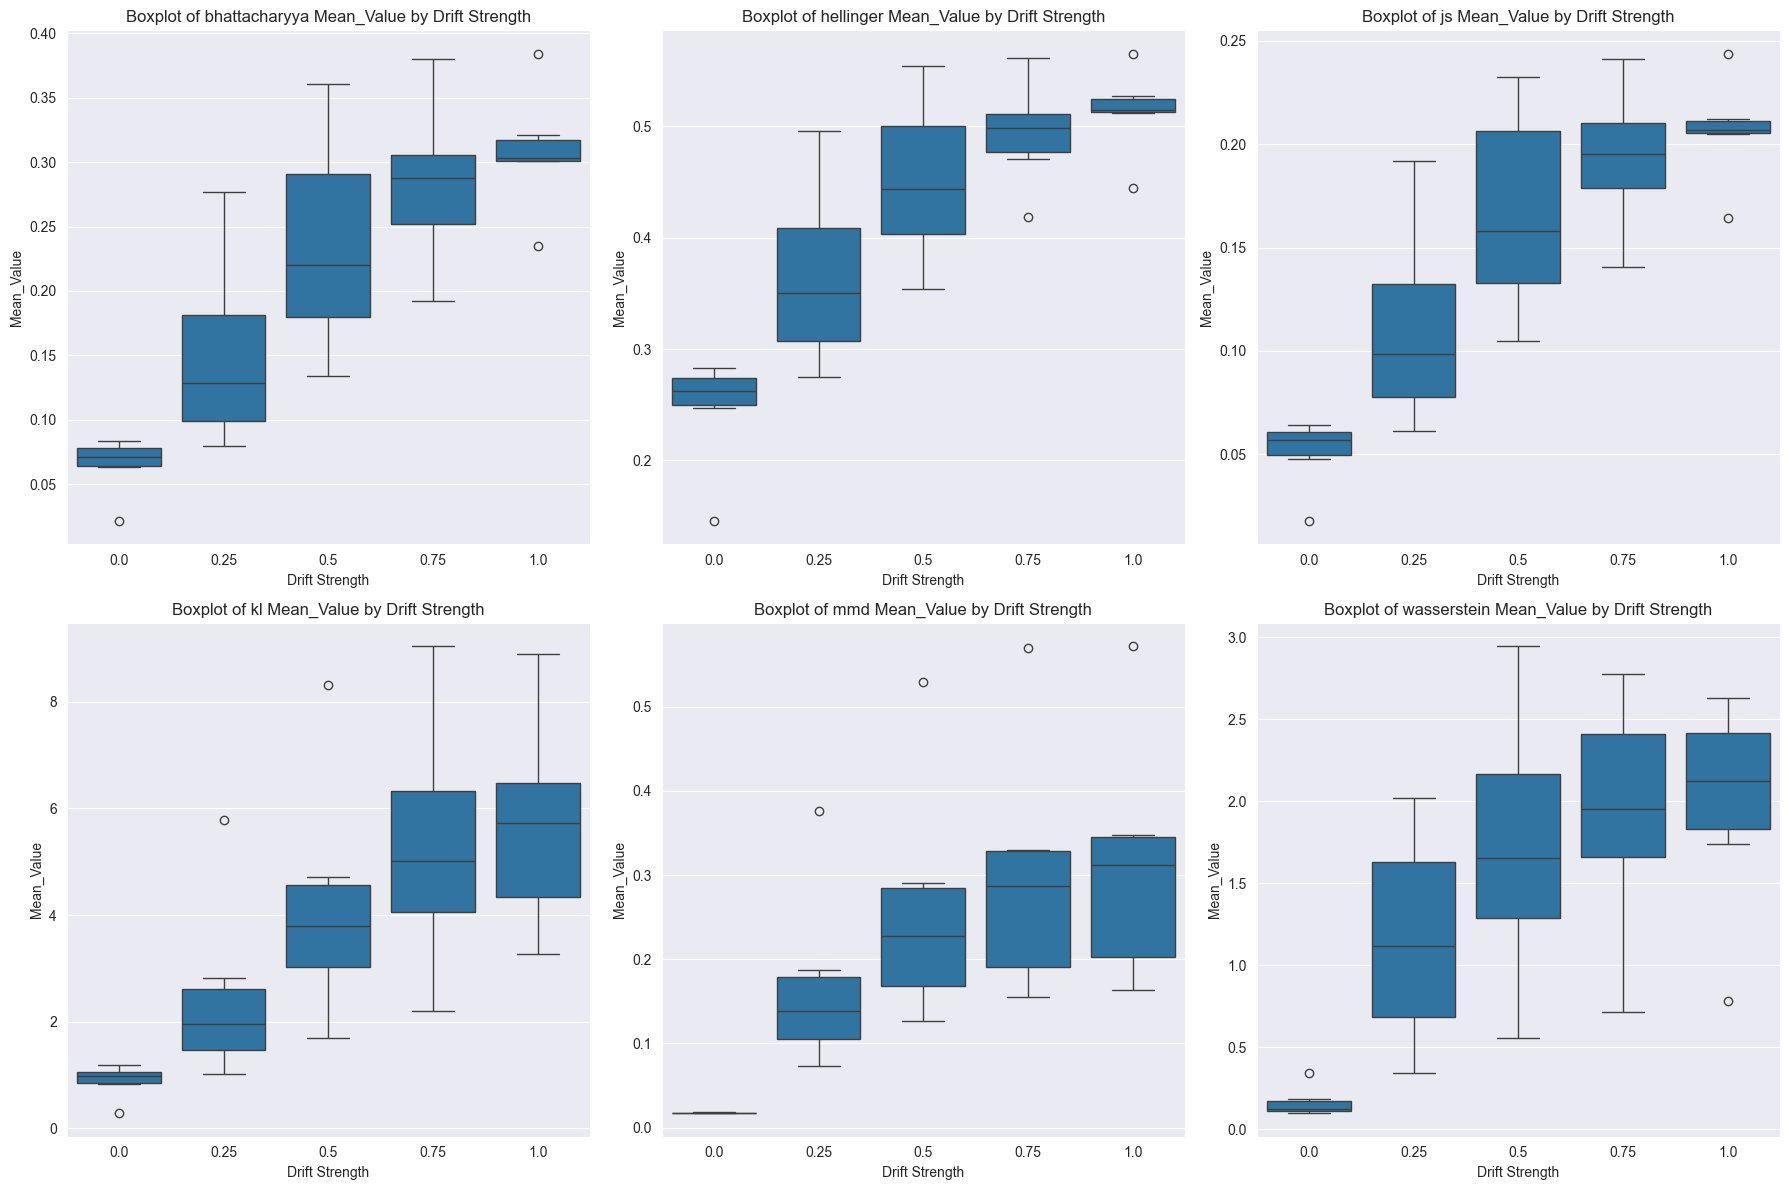

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Group by Measure and compute relative increase and STD per measurement
df_sorted = df_distribution.sort_values(by=["Measure", "Dataset", "Model", "Drift Strength"])

# Fill missing values with a small number
df_sorted["Mean_Value"] = df_sorted["Mean_Value"].fillna(1e-10)

# Compute the relative increase for each measurement
df_sorted["Relative Increase"] = df_sorted.groupby(["Measure", "Dataset", "Model"])["Mean_Value"].pct_change()
df_sorted.loc[:, "Relative Increase"] = df_sorted["Relative Increase"].fillna(0)

# Compute the standard deviation per measurement
std_per_measurement = df_sorted.groupby("Measure")["Std_Value"].mean()

# Compute the relative increase per measurement (average across datasets/models)
relative_increase_per_measurement = df_sorted.groupby("Measure")["Relative Increase"].mean()

# Combine results
results = pd.DataFrame({
    "Relative Increase": relative_increase_per_measurement,
    "STD": std_per_measurement
}).reset_index()

# Replace zero values with a small number
results.replace(0, 1e-10, inplace=True)

# Apply log transformation to Relative Increase and STD
log_transformed = np.log1p(results[["Relative Increase", "STD"]])

# Apply Min-Max scaling
min_max_scaler = MinMaxScaler()
scaled_log_values = min_max_scaler.fit_transform(log_transformed)

# Create a new DataFrame with the transformed values
scaled_log_results = results.copy()
scaled_log_results[["Log-Scaled Relative Increase", "Log-Scaled STD"]] = scaled_log_values

# Order the dataframe by Log-Scaled Relative Increase in descending order
ordered_scaled_log_results = scaled_log_results.sort_values(by="Log-Scaled Relative Increase", ascending=False)

ordered_scaled_log_results = ordered_scaled_log_results.drop(columns=["Relative Increase", "STD"])

# Round the final variables to 4 decimal places
ordered_scaled_log_results[["Log-Scaled Relative Increase", "Log-Scaled STD"]] = ordered_scaled_log_results[[
    "Log-Scaled Relative Increase", "Log-Scaled STD"]].round(4)

print(ordered_scaled_log_results)

# Debugging specific measure
hellinger_data = df_sorted[df_sorted["Measure"] == "hellinger"]
q1 = hellinger_data["Mean_Value"].quantile(0.25)
q3 = hellinger_data["Mean_Value"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
hellinger_data.loc[hellinger_data["Mean_Value"] < lower_bound, "Mean_Value"] = lower_bound
hellinger_data.loc[hellinger_data["Mean_Value"] > upper_bound, "Mean_Value"] = upper_bound

print("Hellinger Data:")
print(hellinger_data[["Dataset", "Model", "Drift Strength", "Mean_Value", "Relative Increase"]])

# Plotting boxplots for all measures in subplots
unique_measures = df_sorted["Measure"].unique()
n_measures = len(unique_measures)
n_cols = 3
n_rows = 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axs = axs.flatten()

for i, measure in enumerate(unique_measures):
    measure_data = df_sorted[df_sorted["Measure"] == measure]
    sns.boxplot(x="Drift Strength", y="Mean_Value", data=measure_data, ax=axs[i])
    axs[i].set_title(f"Boxplot of {measure} Mean_Value by Drift Strength")

# Hide any unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.savefig("data-analysis/data-test/df_distribution_boxplot.png")
plt.show()

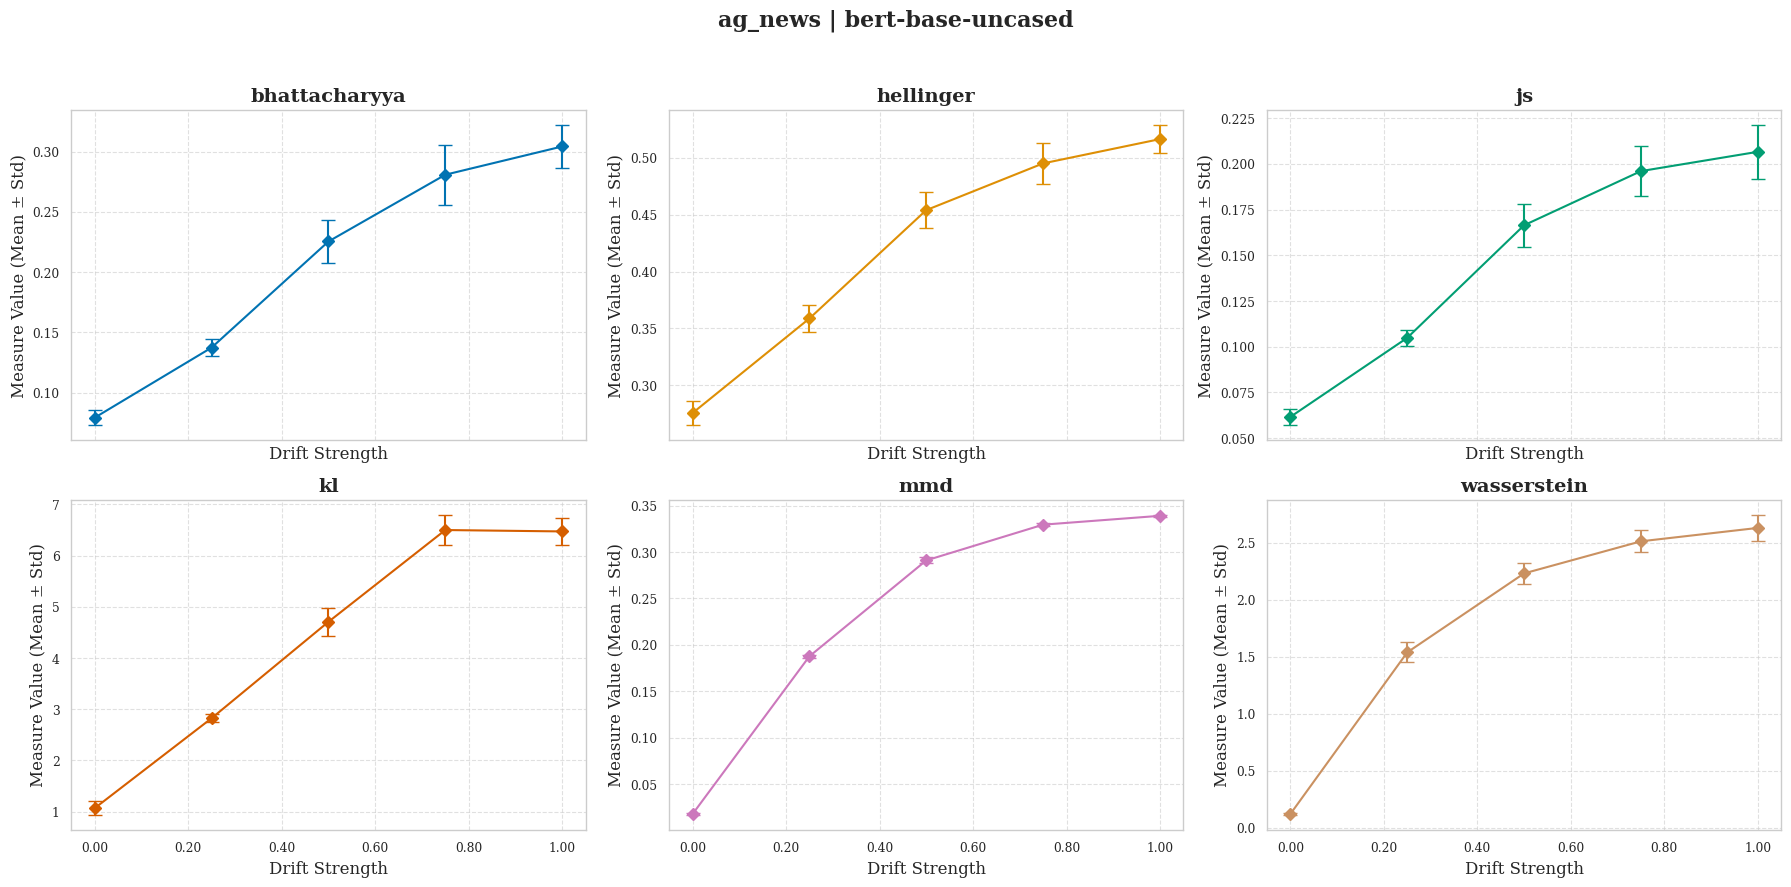

Saved figure: data-analysis/data-test/ag_news_bert-base-uncased_measure_errorbars_optimised.png


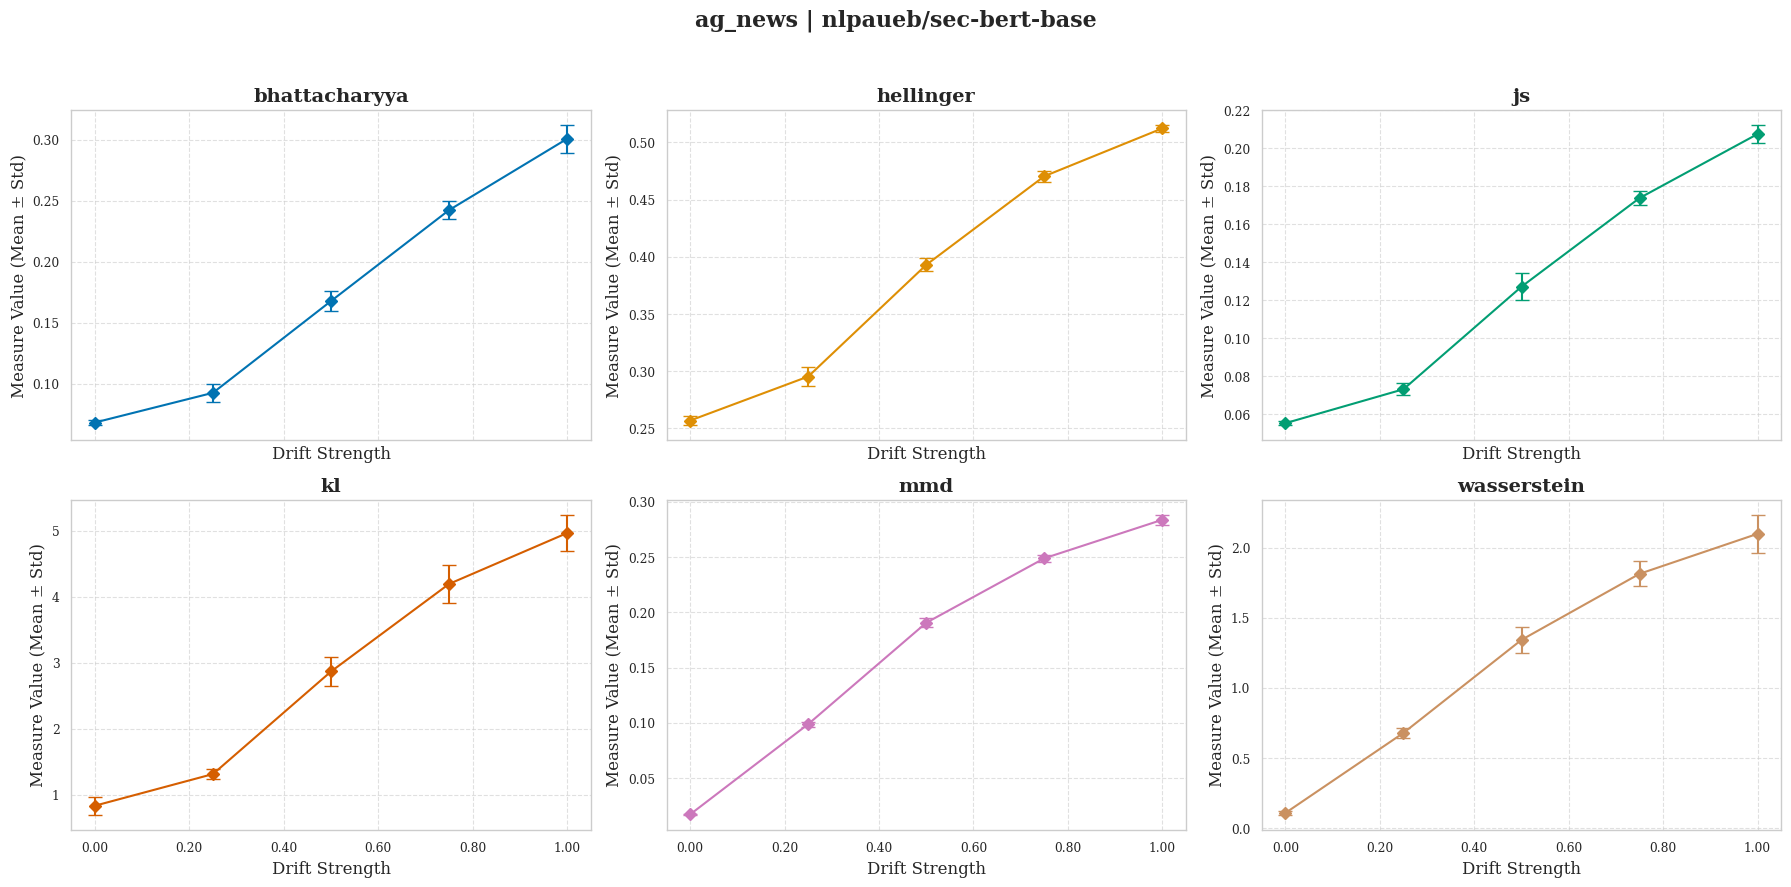

Saved figure: data-analysis/data-test/ag_news_nlpaueb_sec-bert-base_measure_errorbars_optimised.png


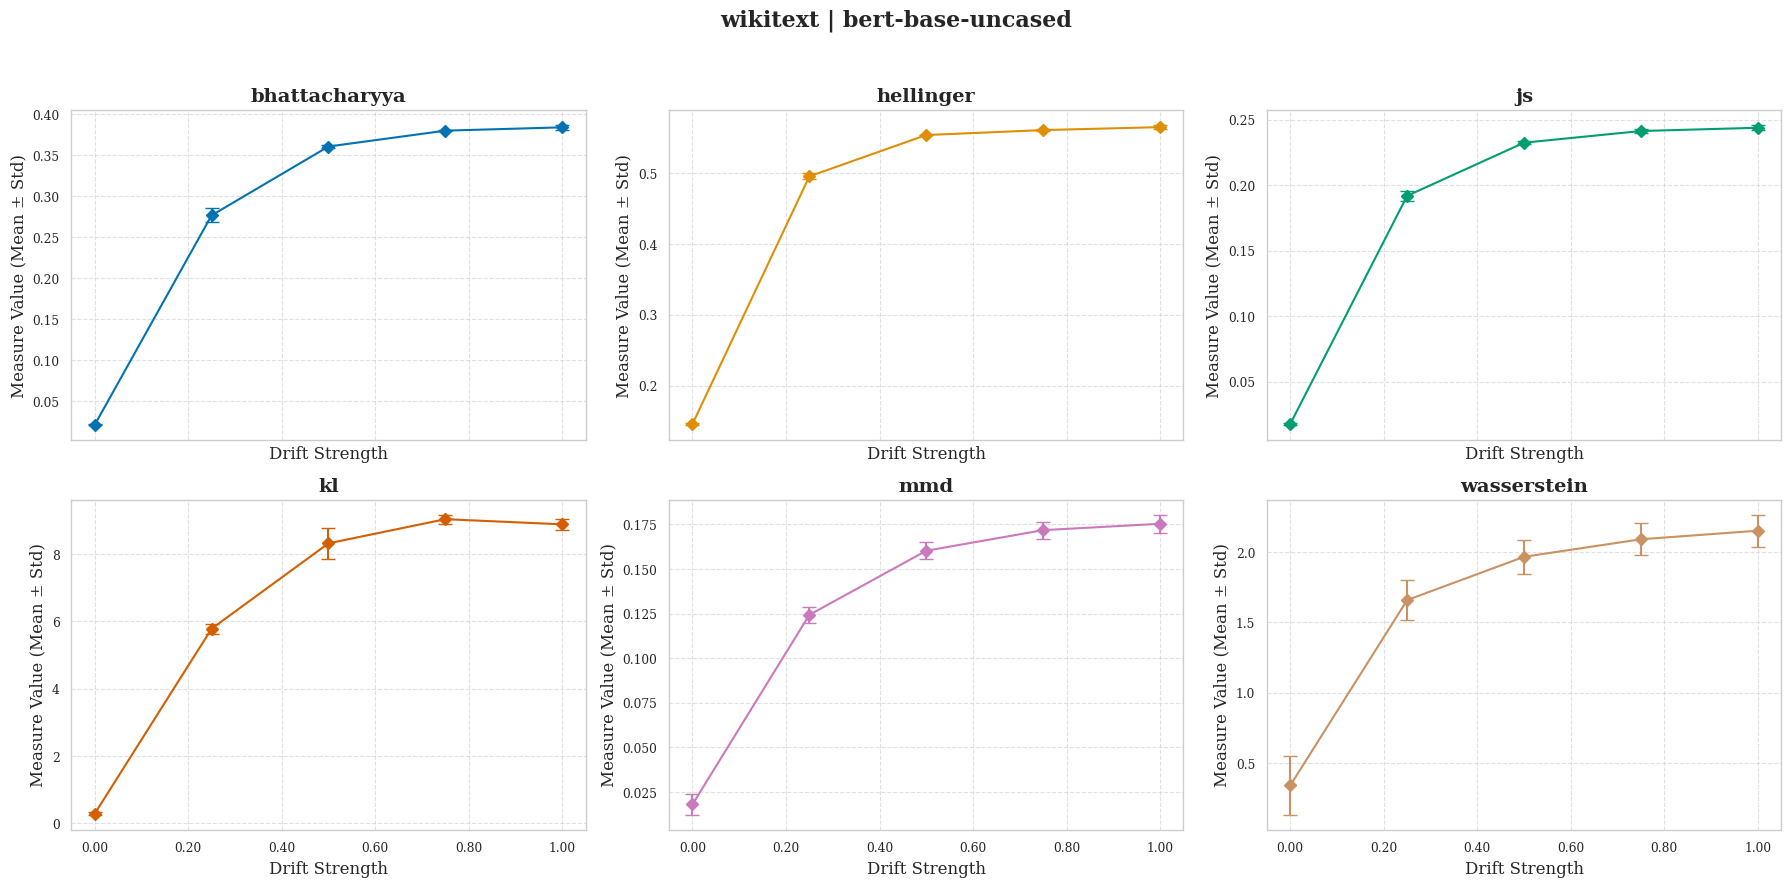

Saved figure: data-analysis/data-test/wikitext_bert-base-uncased_measure_errorbars_optimised.png


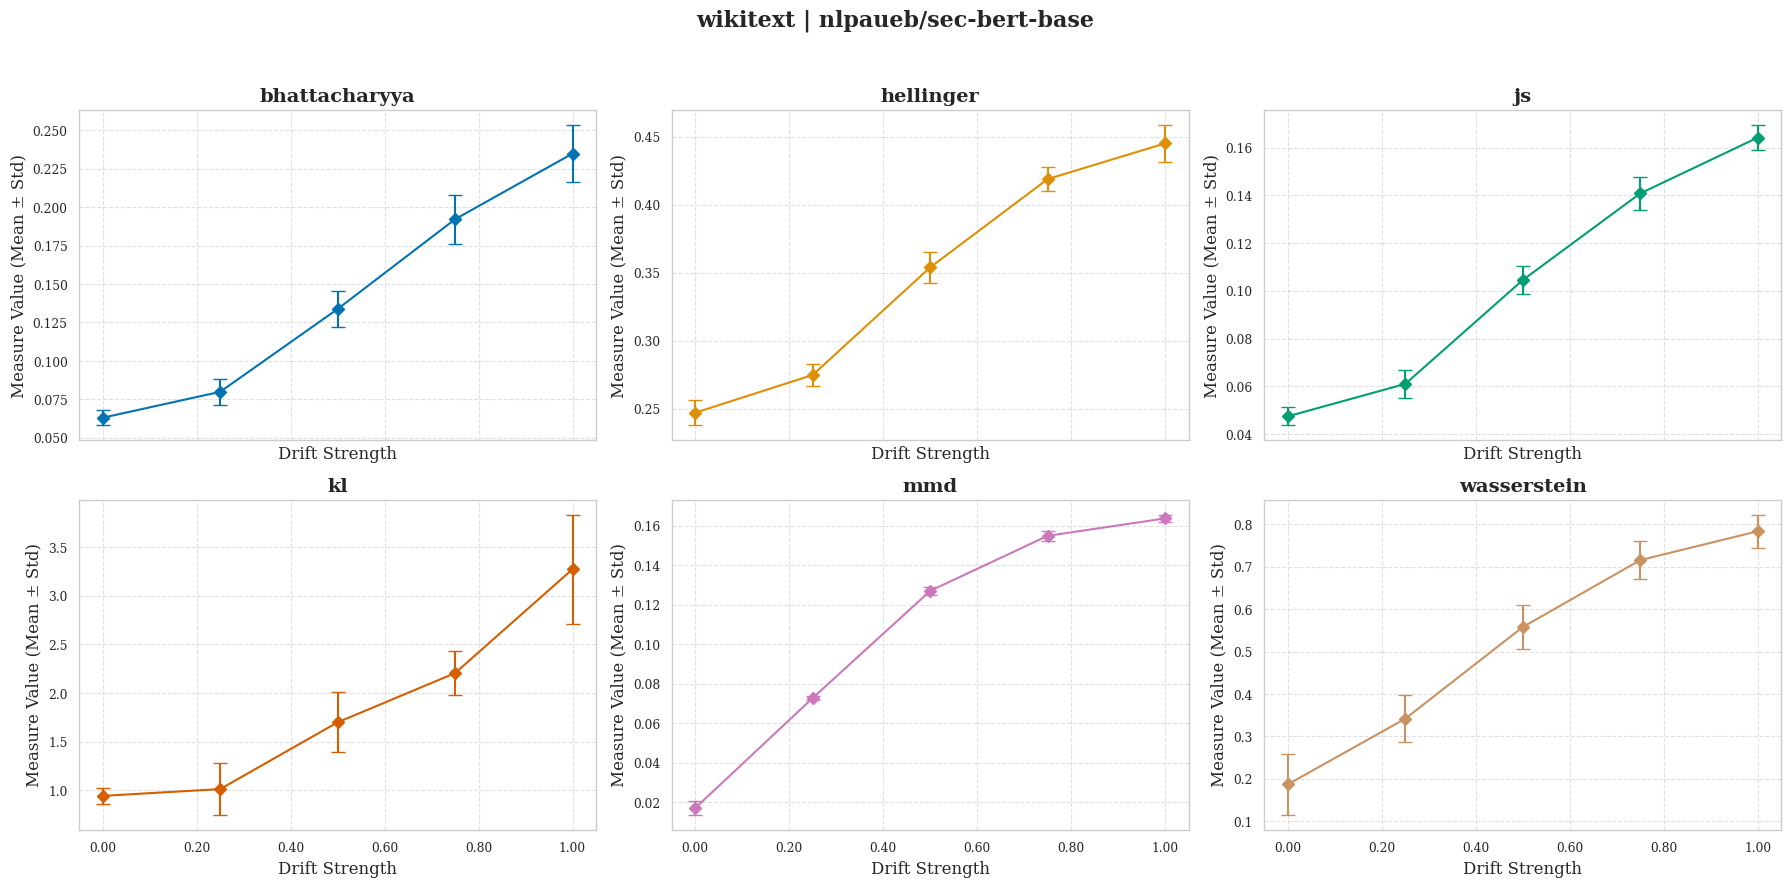

Saved figure: data-analysis/data-test/wikitext_nlpaueb_sec-bert-base_measure_errorbars_optimised.png


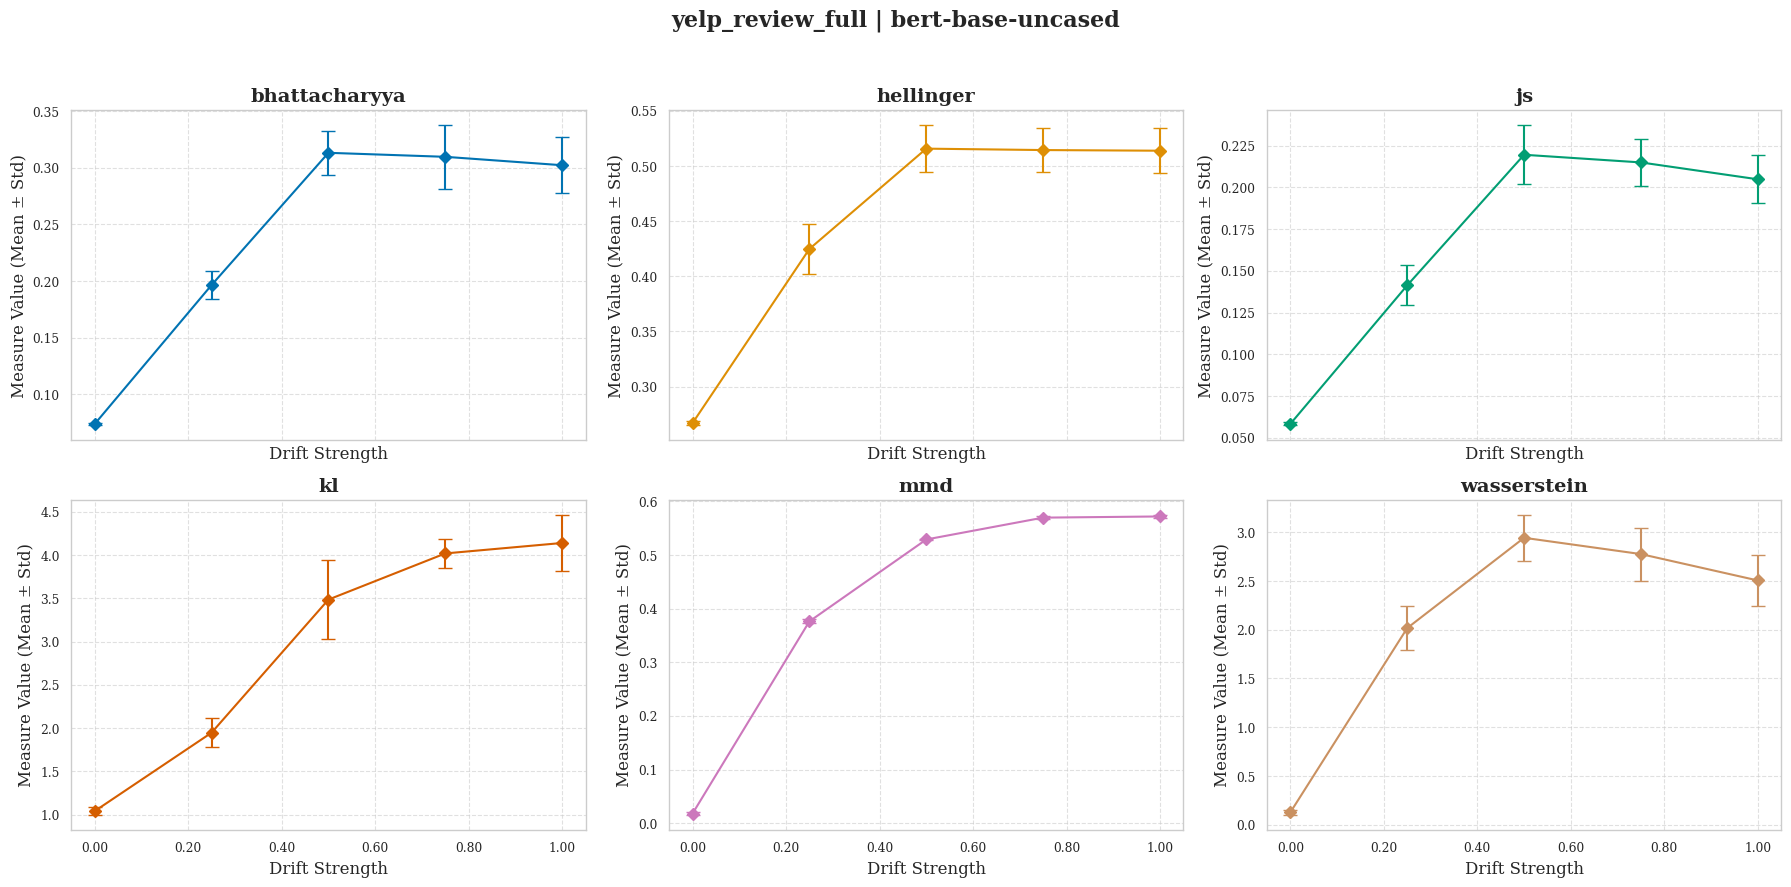

Saved figure: data-analysis/data-test/yelp_review_full_bert-base-uncased_measure_errorbars_optimised.png


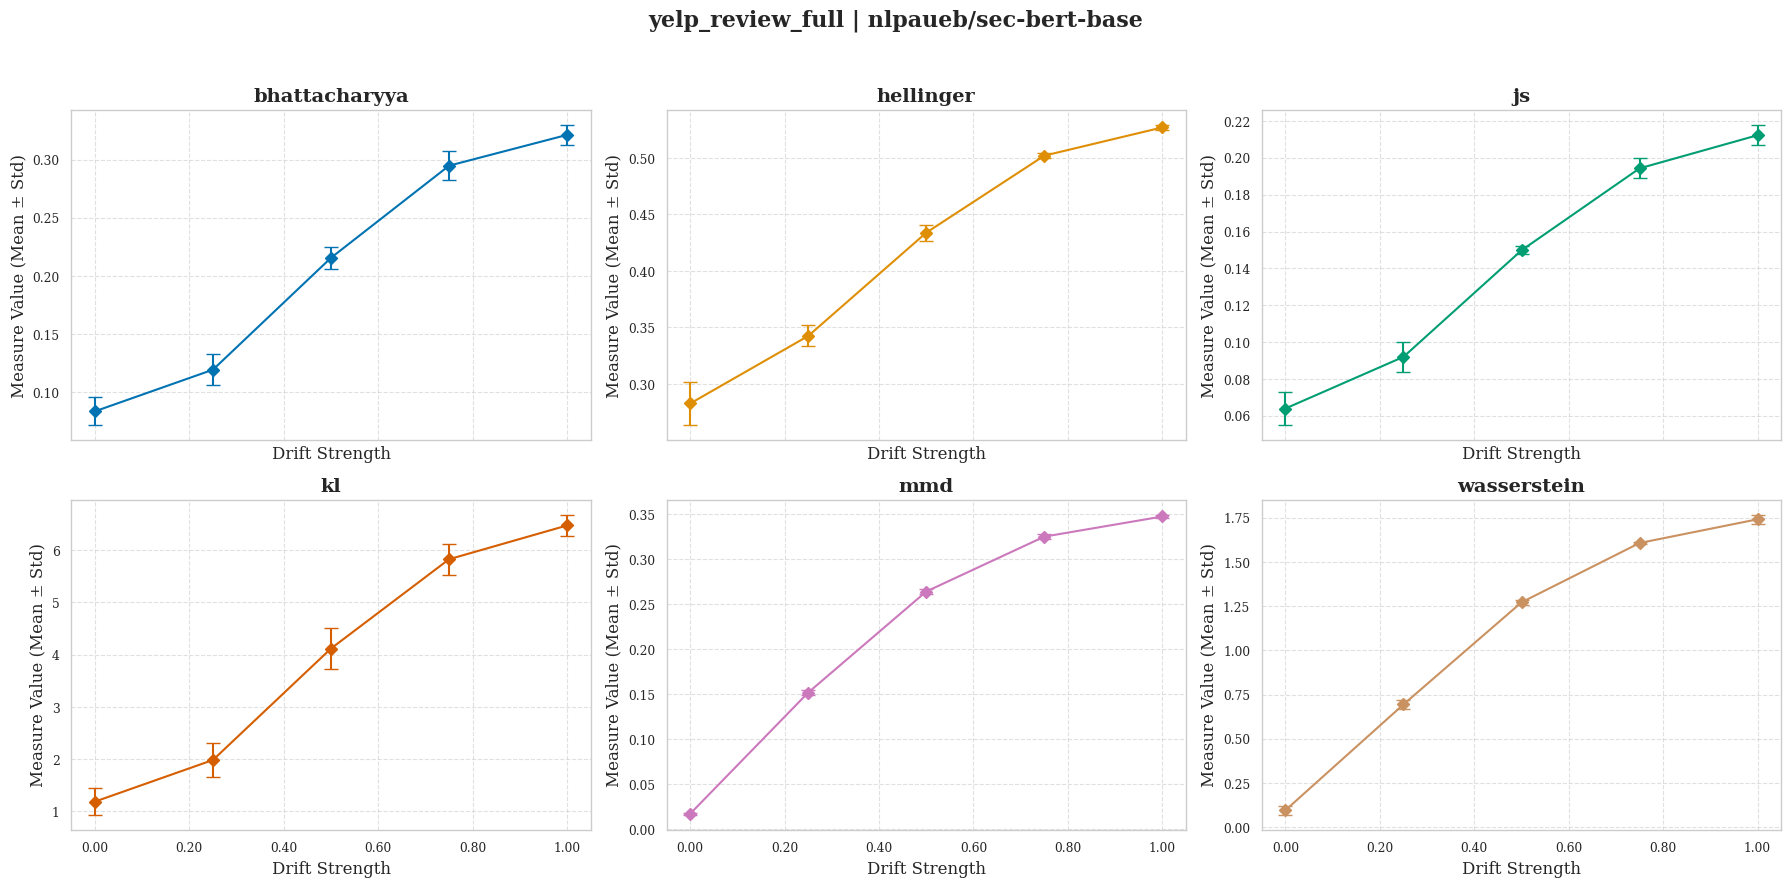

Saved figure: data-analysis/data-test/yelp_review_full_nlpaueb_sec-bert-base_measure_errorbars_optimised.png


In [7]:
# Set academic-style plot aesthetics
sns.set_context("paper")
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "serif"  # Use serif font for academic style


def plot_measure_with_error_bars(df_distance, output_dir="."):
    """
    Aggregate across (Dataset, Model, Measure, Drift Strength) and plot error bars
    for each drift strength.
    """
    grouped = defaultdict(list)
    for _, row in df_distance.iterrows():
        key = (row["Dataset"], row["Model"], row["Measure"], row["Drift Strength"])
        grouped[key].append((row["Mean_Value"], row["Std_Value"]))
    
    aggregated_data = []
    for key, values in grouped.items():
        dataset_name, model_name, measure, drift_strength = key
        mean_vals = [v[0] for v in values]
        std_vals = [v[1] for v in values]
        aggregated_data.append({
            "dataset_name": dataset_name,
            "model_name": model_name,
            "measure": measure,
            "drift_strength": drift_strength,
            "mean_val": np.mean(mean_vals),
            "std_val": np.mean(std_vals)
        })
    
    grouped_by_model = defaultdict(list)
    for row in aggregated_data:
        grouped_by_model[(row["dataset_name"], row["model_name"])].append(row)
    
    for (dataset_name, model_name), rows in grouped_by_model.items():
        measures = sorted(set(r["measure"] for r in rows))
        n_measures = len(measures)
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16, fontweight='bold')
    
        colors = sns.color_palette("colorblind", n_colors=n_measures)  # Use colorblind-friendly colors
    
        for i, measure in enumerate(measures):
            ax = axs[i]
            measure_rows = [r for r in rows if r["measure"] == measure]
            sorted_rows = sorted(measure_rows, key=lambda x: x["drift_strength"])
    
            x_vals = [r["drift_strength"] for r in sorted_rows]
            y_vals = [r["mean_val"] for r in sorted_rows]
            e_vals = [r["std_val"] for r in sorted_rows]
    
            ax.errorbar(x_vals, y_vals, yerr=e_vals, fmt='D-', capsize=5, markersize=6, 
                        linewidth=1.5, color=colors[i], label=measure)
    
            ax.set_title(measure, fontsize=14, fontweight='bold')
            ax.set_xlabel("Drift Strength", fontsize=12)
            ax.set_ylabel("Measure Value (Mean ± Std)", fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)
            # ax.legend(loc="upper left", bbox_to_anchor=(1,1), fontsize=10)
    
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))  # Format x-axis labels
    
        for j in range(i+1, n_rows * n_cols):
            axs[j].set_visible(False)
    
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_measure_errorbars_optimised.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        plt.show()
        print(f"Saved figure: {save_path}")

# Example usage:
plot_measure_with_error_bars(df_distribution, output_dir="data-analysis/data-test")

In [8]:
df_distance.head()

,distance_name,drift_strength,pca,final_similarity,seed,Dataset,Model
0,mahalanobis,0.00,False,0.822321,0,yelp_review_full,nlpaueb/sec-bert-base
1,mahalanobis,0.00,True,0.152716,0,yelp_review_full,nlpaueb/sec-bert-base
2,mahalanobis,0.25,False,1.473224,0,yelp_review_full,nlpaueb/sec-bert-base
3,mahalanobis,0.25,True,0.618627,0,yelp_review_full,nlpaueb/sec-bert-base
4,mahalanobis,0.50,False,2.016730,0,yelp_review_full,nlpaueb/sec-bert-base


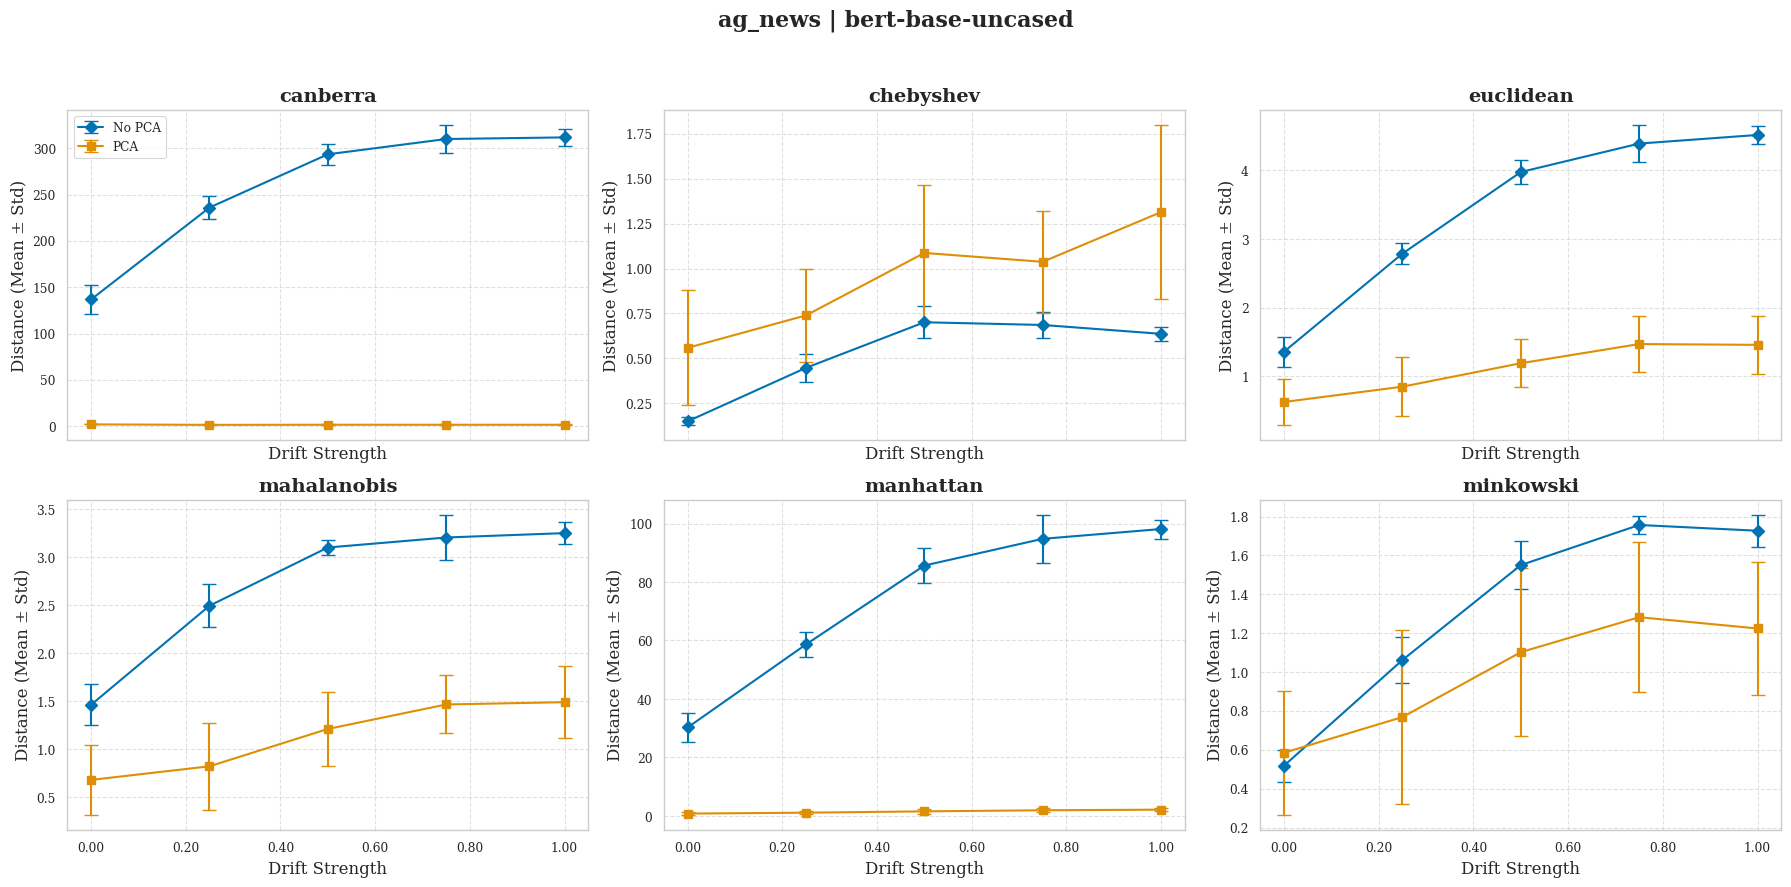

Saved figure: data-analysis/data-test/ag_news_bert-base-uncased_distances_errorbars.png


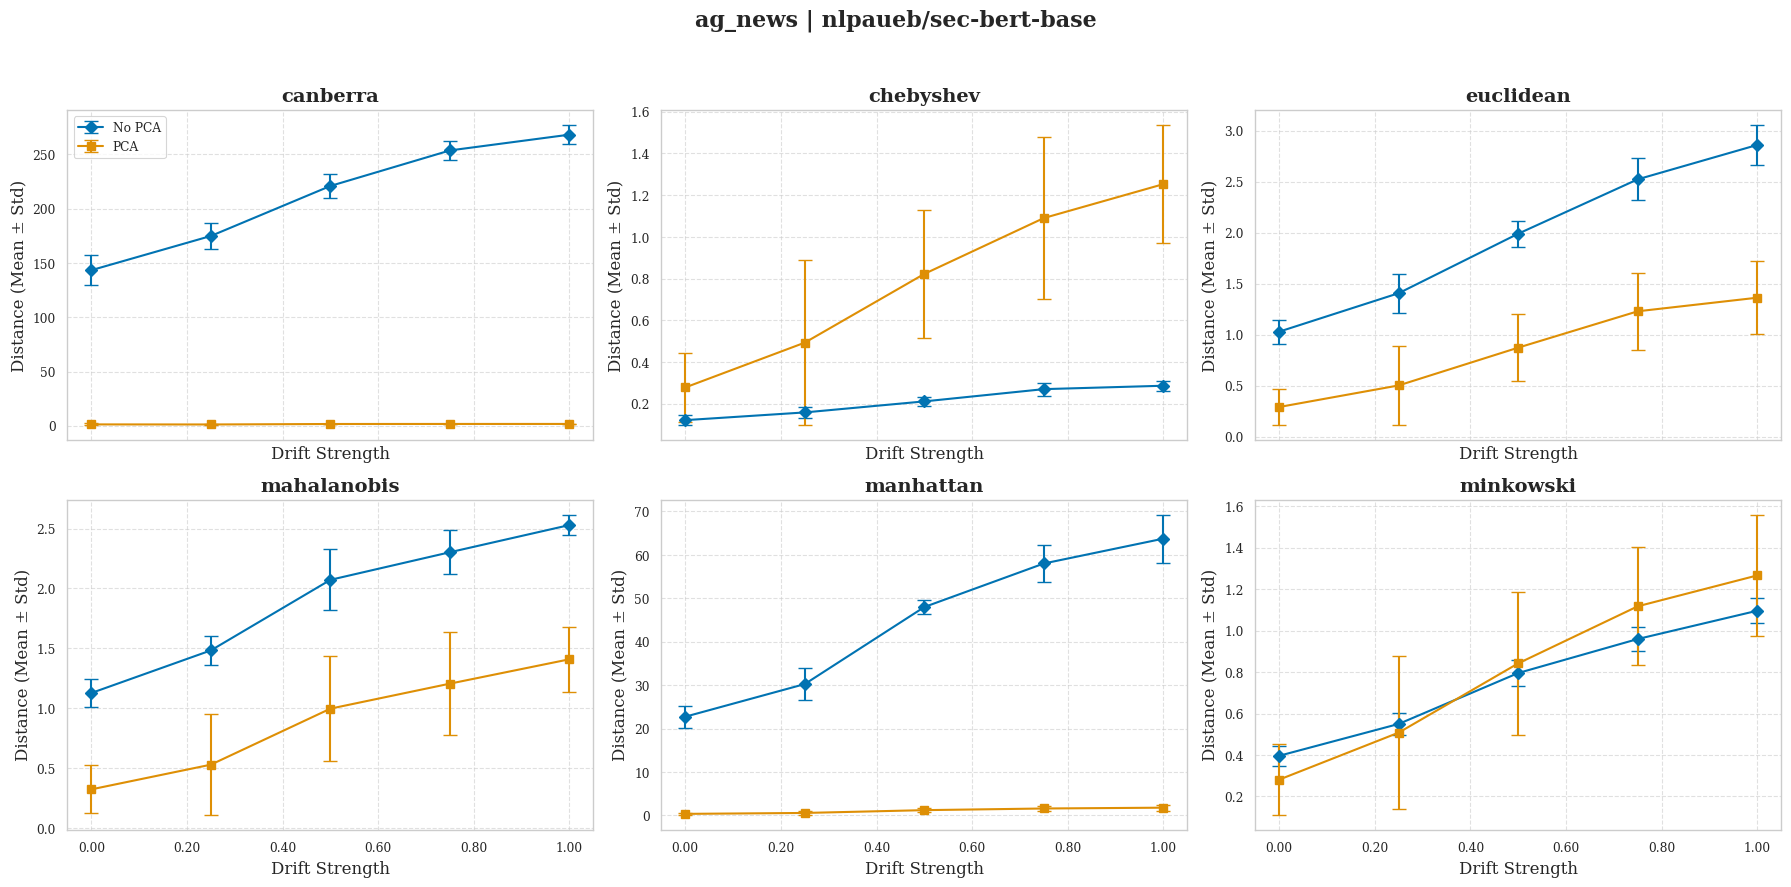

Saved figure: data-analysis/data-test/ag_news_nlpaueb_sec-bert-base_distances_errorbars.png


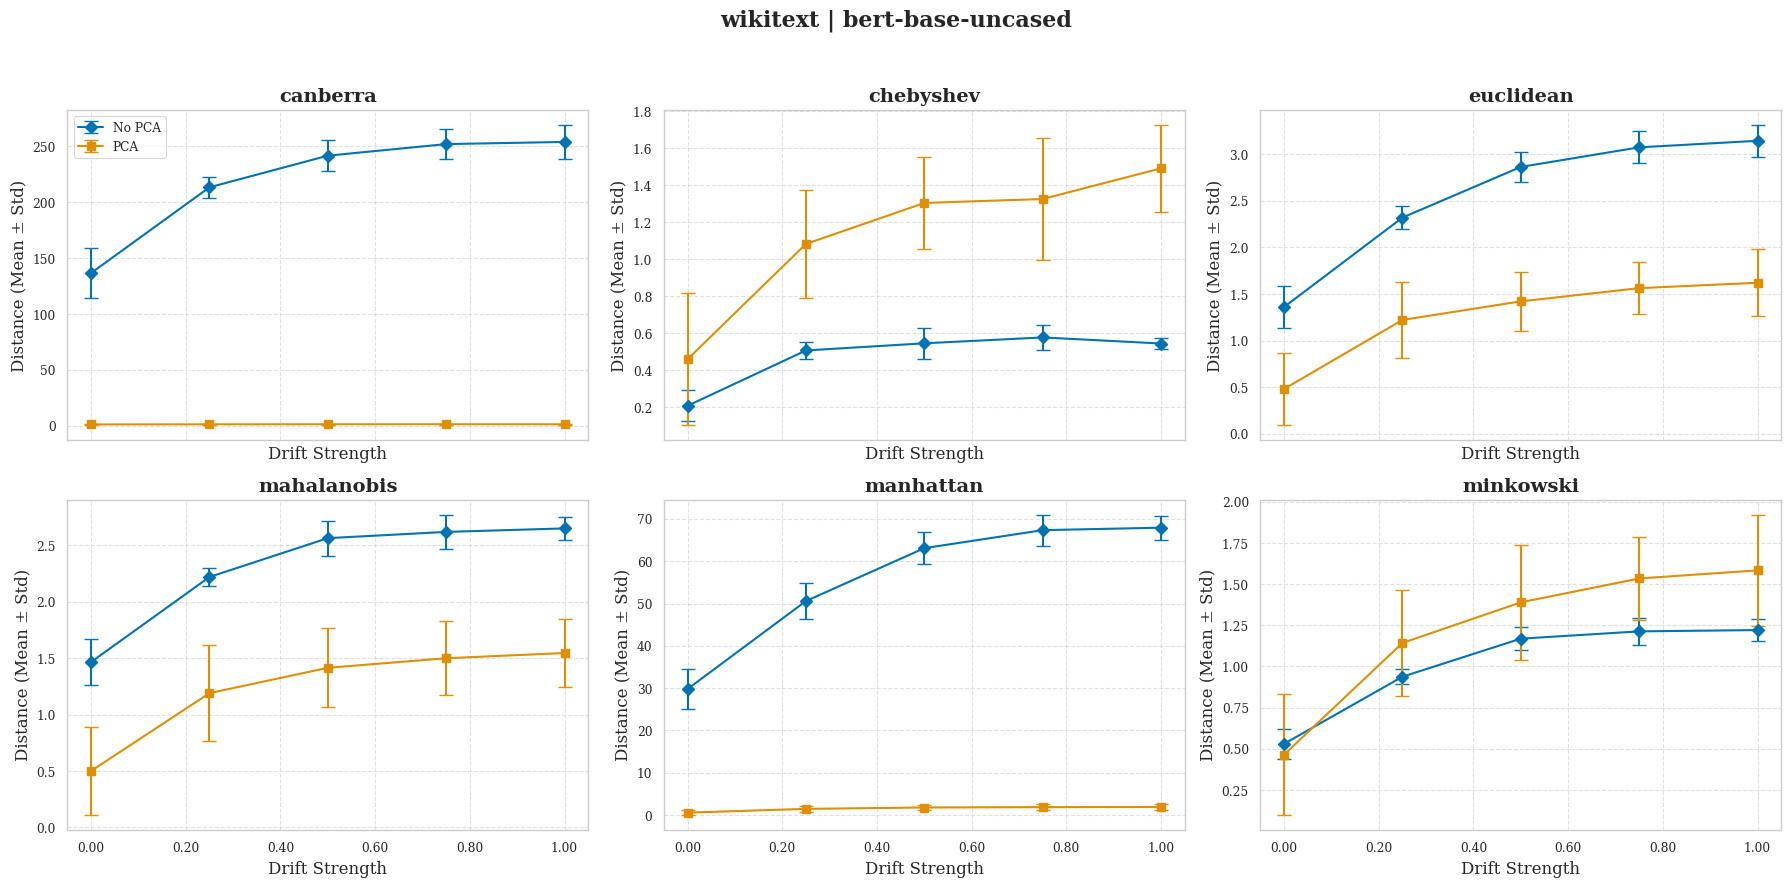

Saved figure: data-analysis/data-test/wikitext_bert-base-uncased_distances_errorbars.png


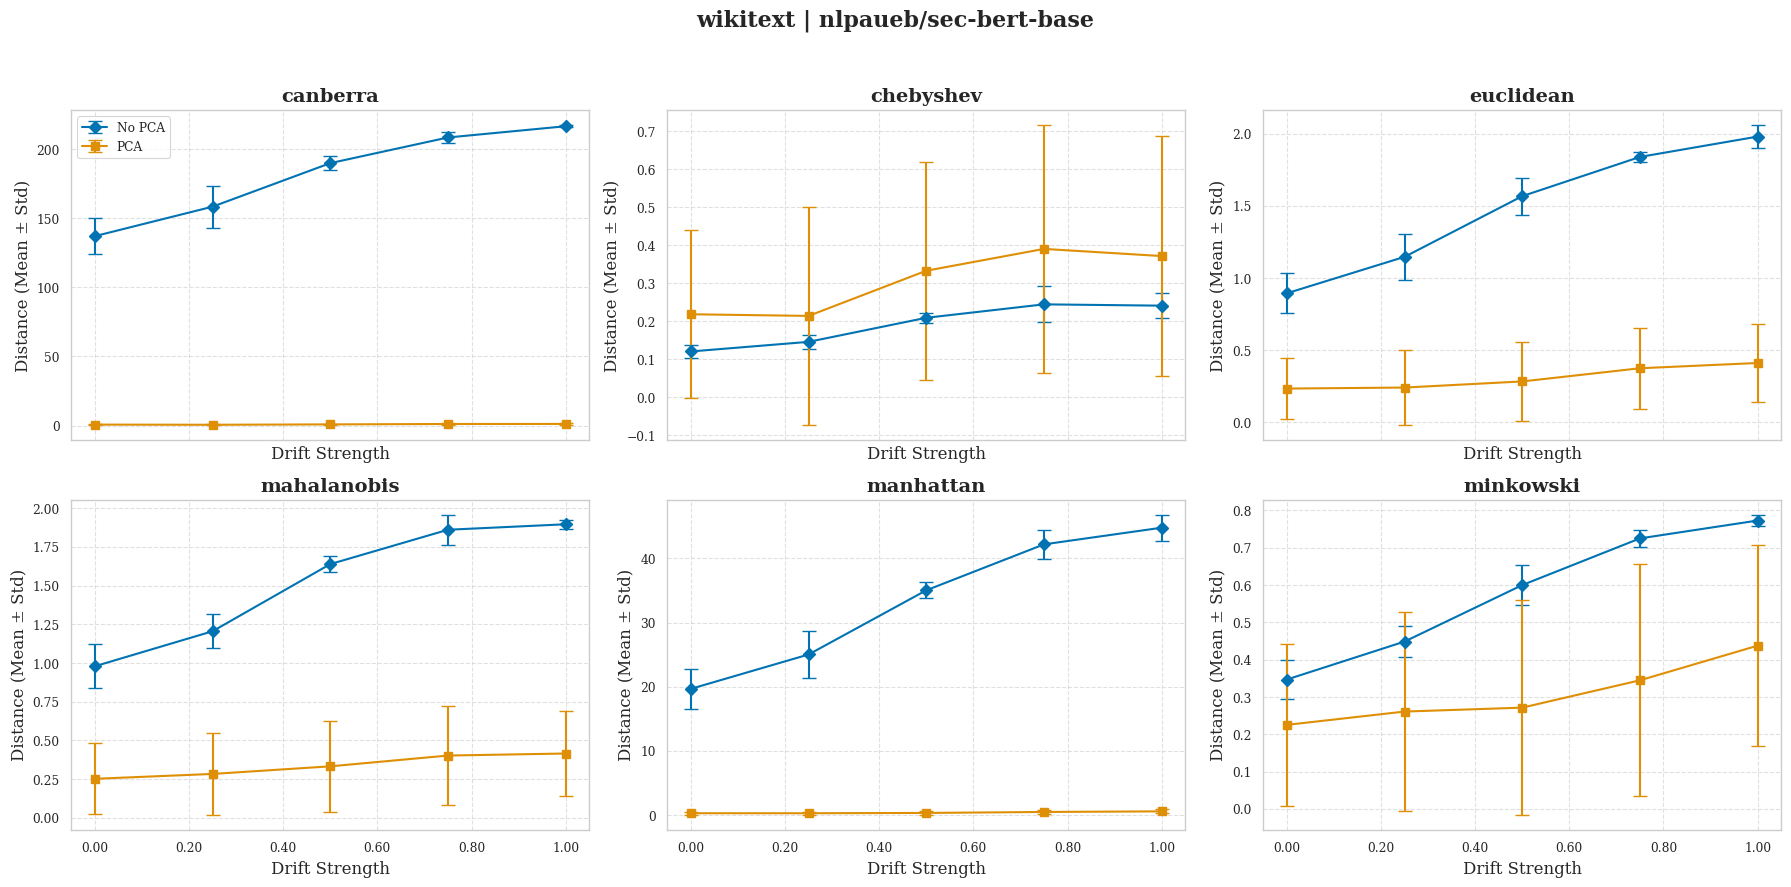

Saved figure: data-analysis/data-test/wikitext_nlpaueb_sec-bert-base_distances_errorbars.png


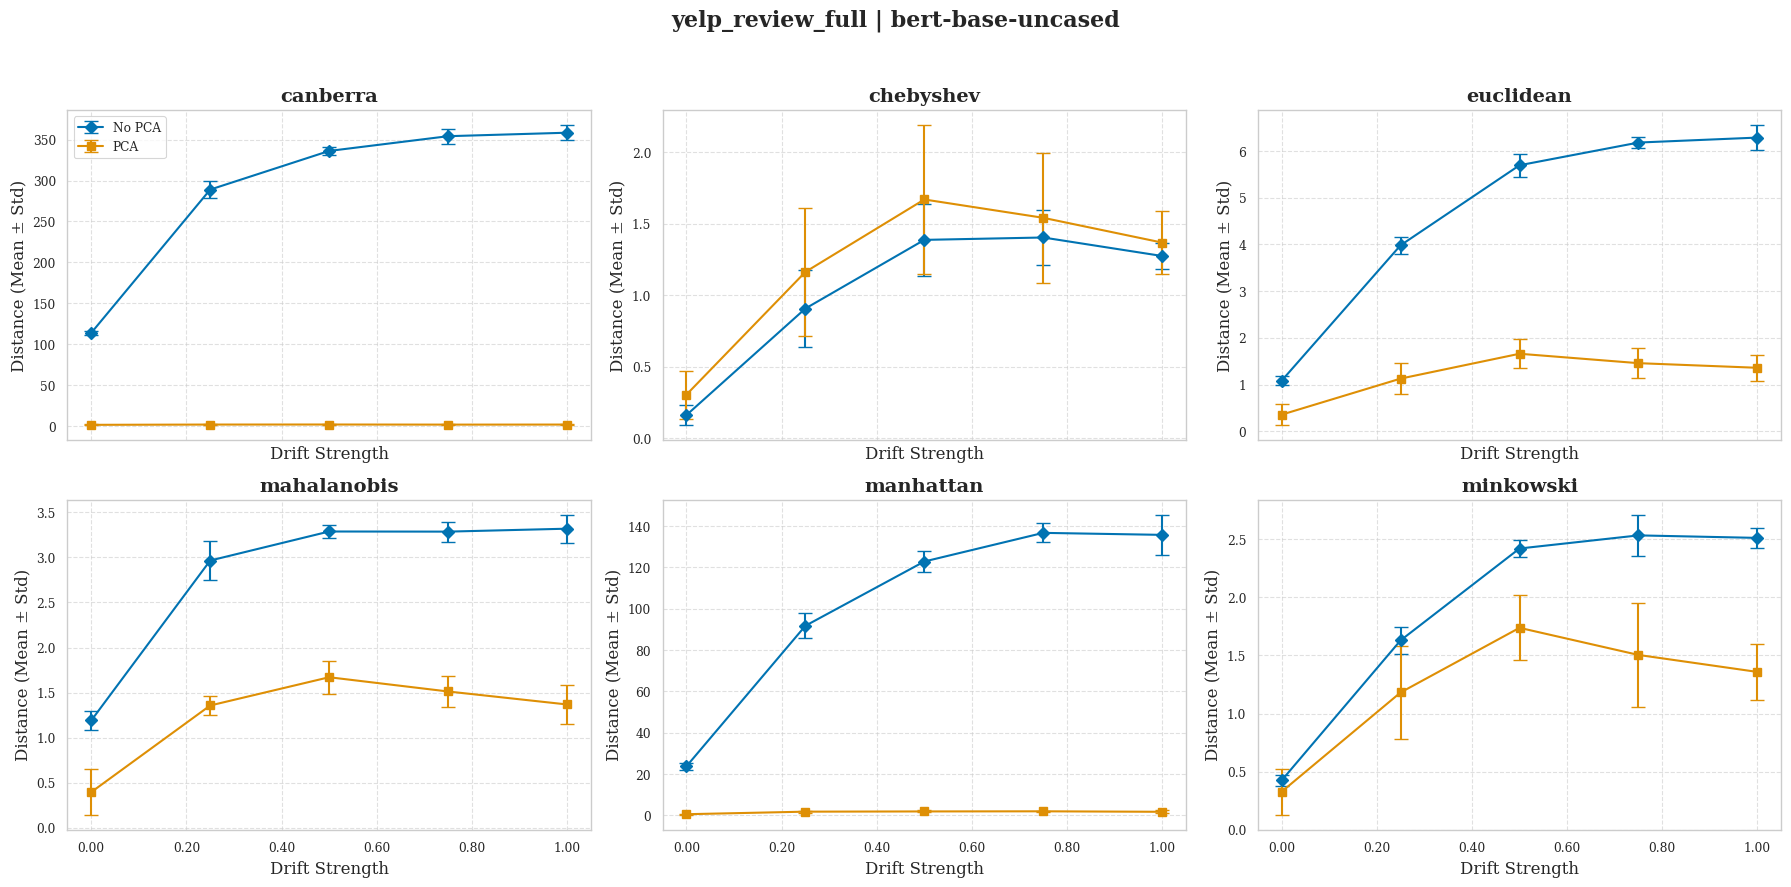

Saved figure: data-analysis/data-test/yelp_review_full_bert-base-uncased_distances_errorbars.png


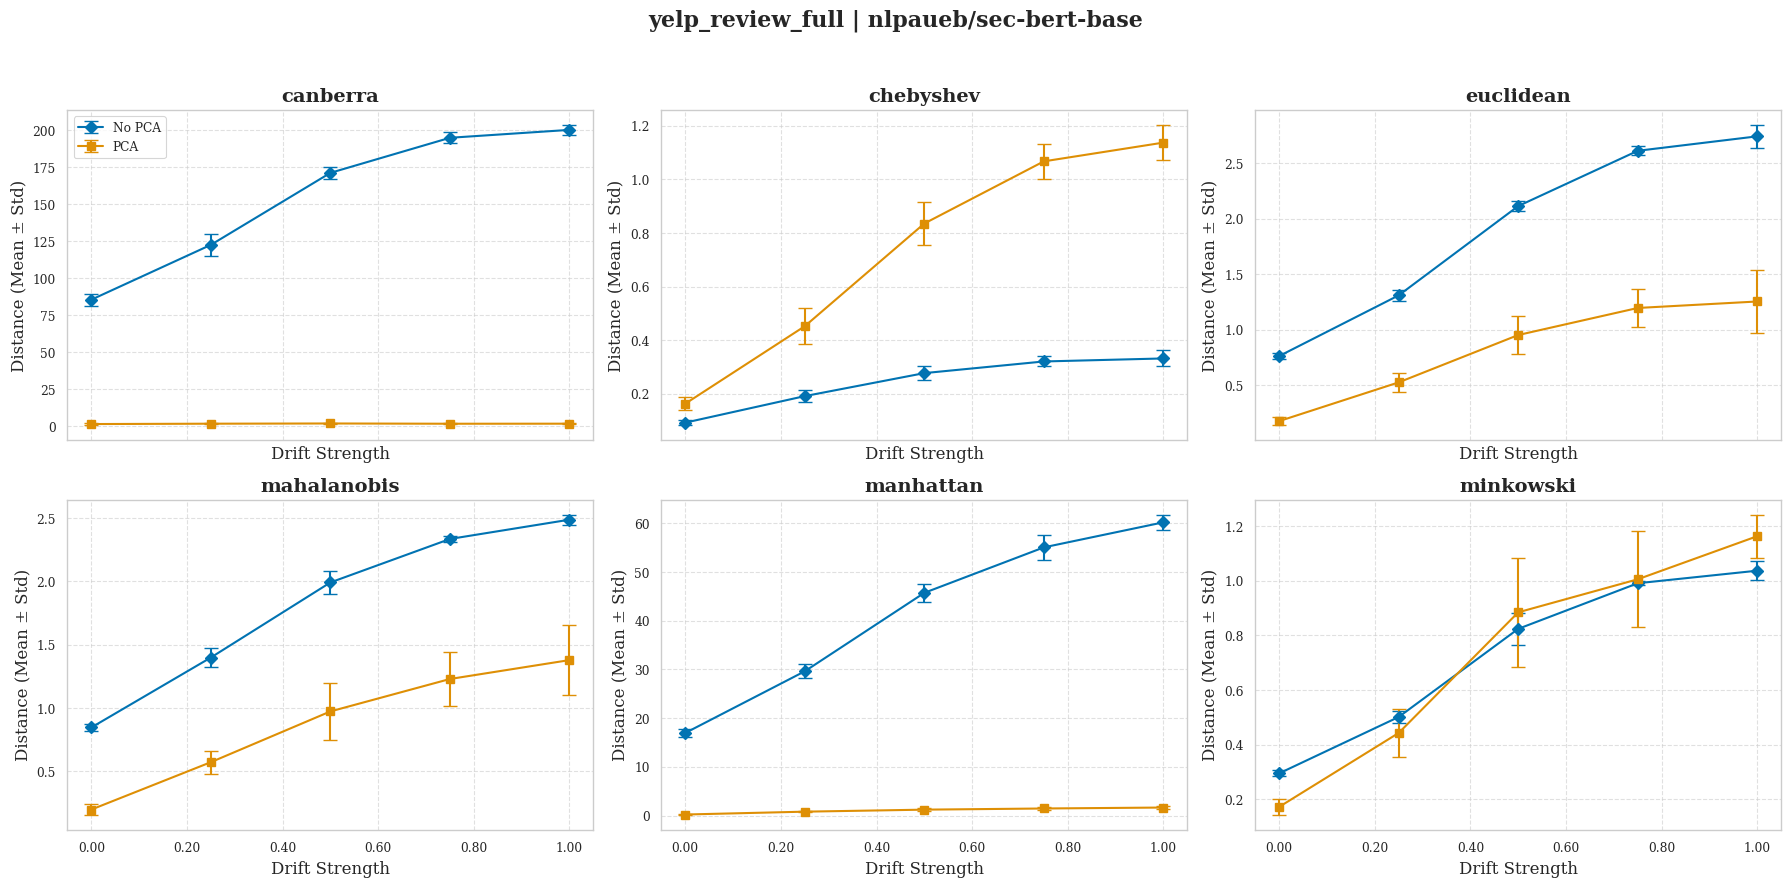

Saved figure: data-analysis/data-test/yelp_review_full_nlpaueb_sec-bert-base_distances_errorbars.png


In [9]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic-style plot aesthetics
sns.set_context("paper")
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "serif"  # Use serif font for academic style

def plot_distance_with_error_bars(df, output_dir="."):
    """
    For each combination of (Dataset, Model, distance_name, pca, drift_strength),
    aggregate the final_similarity values (across seeds) by computing the mean and std.
    Then, for each (Dataset, Model), produce a plot with error bars (mean ± std) for each
    distance_name, comparing "No PCA" and "PCA" lines.
    
    Parameters:
      df         : pandas DataFrame with columns:
                   "distance_name", "drift_strength", "pca", "final_similarity", 
                   "seed", "Dataset", "Model"
      output_dir : Directory where plots will be saved.
    """
    # Aggregate across seeds: group by Dataset, Model, distance_name, pca, drift_strength.
    aggregated = df.groupby(["Dataset", "Model", "distance_name", "pca", "drift_strength"])["final_similarity"] \
                   .agg(["mean", "std"]).reset_index()
    
    # Rename columns for consistency with plotting code.
    aggregated.rename(columns={
        "Dataset": "dataset_name",
        "Model": "model_name",
        "mean": "mean_val",
        "std": "std_val",
        "drift_strength": "drift_strength"
    }, inplace=True)
    
    # Group by (dataset_name, model_name) to generate a separate plot per combination.
    grouped_by_model = defaultdict(list)
    for _, row in aggregated.iterrows():
        key = (row["dataset_name"], row["model_name"])
        grouped_by_model[key].append(row)
    
    # For each dataset/model combination, create a plot.
    for (dataset_name, model_name), rows in grouped_by_model.items():
        # Get sorted list of unique distance names.
        dist_names = sorted({row["distance_name"] for row in rows})
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True)
        
        # Flatten axs for easy iteration.
        if n_dists == 1:
            axs = [axs]
        else:
            axs = axs.flatten()
        
        # Use a colorblind-friendly palette for the two lines (No PCA and PCA).
        colors = sns.color_palette("colorblind", n_colors=2)
        
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16, fontweight='bold')
        
        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            # Filter data for the current distance.
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            
            # Separate rows by PCA flag.
            no_pca = sorted([r for r in dist_rows if r["pca"] == False],
                            key=lambda x: x["drift_strength"])
            pca = sorted([r for r in dist_rows if r["pca"] == True],
                         key=lambda x: x["drift_strength"])
            
            # Extract x-values (drift_strength), y-values (mean_val), and errors (std_val).
            x_no_pca = [r["drift_strength"] for r in no_pca]
            y_no_pca = [r["mean_val"] for r in no_pca]
            e_no_pca = [r["std_val"] for r in no_pca]
            
            x_pca = [r["drift_strength"] for r in pca]
            y_pca = [r["mean_val"] for r in pca]
            e_pca = [r["std_val"] for r in pca]
            
            # Plot error bars for "No PCA" using a diamond marker.
            ax.errorbar(x_no_pca, y_no_pca, yerr=e_no_pca,
                        fmt='D-', capsize=5, markersize=6, linewidth=1.5,
                        color=colors[0], label="No PCA")
            
            # Plot error bars for "PCA" using a square marker.
            ax.errorbar(x_pca, y_pca, yerr=e_pca,
                        fmt='s-', capsize=5, markersize=6, linewidth=1.5,
                        color=colors[1], label="PCA")
            
            ax.set_title(dist_name, fontsize=14, fontweight='bold')
            ax.set_xlabel("Drift Strength", fontsize=12)
            ax.set_ylabel("Distance (Mean ± Std)", fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
            
            # Show legend only on the first subplot.
            if i == 0:
                ax.legend()
        
        # Hide any unused subplots.
        for j in range(i+1, n_rows * n_cols):
            axs[j].set_visible(False)
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(output_dir, fname)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        plt.show()
        print(f"Saved figure: {save_path}")

# Example usage:
# Assuming your dataframe is named df_distribution and you want to save plots in a given output directory:
plot_distance_with_error_bars(df_distance, output_dir="data-analysis/data-test")


In [10]:
df_distance

,distance_name,drift_strength,pca,final_similarity,seed,Dataset,Model
0,mahalanobis,0.00,False,0.822321,0,yelp_review_full,nlpaueb/sec-bert-base
1,mahalanobis,0.00,True,0.152716,0,yelp_review_full,nlpaueb/sec-bert-base
2,mahalanobis,0.25,False,1.473224,0,yelp_review_full,nlpaueb/sec-bert-base
3,mahalanobis,0.25,True,0.618627,0,yelp_review_full,nlpaueb/sec-bert-base
4,mahalanobis,0.50,False,2.016730,0,yelp_review_full,nlpaueb/sec-bert-base
...,...,...,...,...,...,...,...
1075,canberra,0.50,True,1.354779,2,ag_news,bert-base-uncased
1076,canberra,0.75,False,295.889099,2,ag_news,bert-base-uncased
1077,canberra,0.75,True,1.228447,2,ag_news,bert-base-uncased
1078,canberra,1.00,False,302.747559,2,ag_news,bert-base-uncased


In [11]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Rename columns for consistency with the script
df_distance.rename(columns={
    "distance_name": "Measure",
    "drift_strength": "Drift Strength",
    "final_similarity": "Mean_Value",
    "seed": "Seed"
}, inplace=True)

# Include PCA as a separate grouping factor
df_grouped_pca = df_distance.groupby(["Measure", "Dataset", "Model", "Drift Strength", "pca"]).agg(
    Mean_Value=("Mean_Value", "mean"),
    Std_Value=("Mean_Value", "std")
).reset_index()

# Sort the DataFrame
df_sorted_pca = df_grouped_pca.sort_values(by=["Measure", "Dataset", "Model", "Drift Strength", "pca"])

# Compute the relative increase for each measurement
df_sorted_pca["Relative Increase"] = df_sorted_pca.groupby(["Measure", "Dataset", "Model", "pca"])["Mean_Value"].pct_change()

# Compute the standard deviation per measurement
std_per_measurement_pca = df_sorted_pca.groupby(["Measure", "pca"])["Std_Value"].mean()

# Compute the relative increase per measurement (average across datasets/models)
relative_increase_per_measurement_pca = df_sorted_pca.groupby(["Measure", "pca"])["Relative Increase"].mean()

# Combine results
results_pca = pd.DataFrame({
    "Relative Increase": relative_increase_per_measurement_pca,
    "STD": std_per_measurement_pca
}).reset_index()

# Apply log transformation to Relative Increase and STD
log_transformed_pca = np.log1p(results_pca[["Relative Increase", "STD"]])

# Apply Min-Max scaling
scaled_log_values_pca = min_max_scaler.fit_transform(log_transformed_pca)

# Create a new DataFrame with the transformed values
scaled_log_results_pca = results_pca.copy()
scaled_log_results_pca[["Log-Scaled Relative Increase", "Log-Scaled STD"]] = scaled_log_values_pca

# Order the dataframe by Log-Scaled Relative Increase in descending order
ordered_scaled_log_results_pca = scaled_log_results_pca.sort_values(by="Log-Scaled Relative Increase", ascending=False)

# Display the final results
ordered_scaled_log_results_pca = ordered_scaled_log_results_pca.drop(columns=["STD", "Relative Increase"])

ordered_scaled_log_results_pca

,Measure,pca,Log-Scaled Relative Increase,Log-Scaled STD
2,chebyshev,False,1.000000,0.000000
9,manhattan,True,0.963019,0.135837
3,chebyshev,True,0.907007,0.079874
11,minkowski,True,0.885016,0.082354
5,euclidean,True,0.876270,0.085986
7,mahalanobis,True,0.837328,0.083261
10,minkowski,False,0.778673,0.000940
8,manhattan,False,0.771048,0.646220
4,euclidean,False,0.764809,0.032890
6,mahalanobis,False,0.483460,0.024199


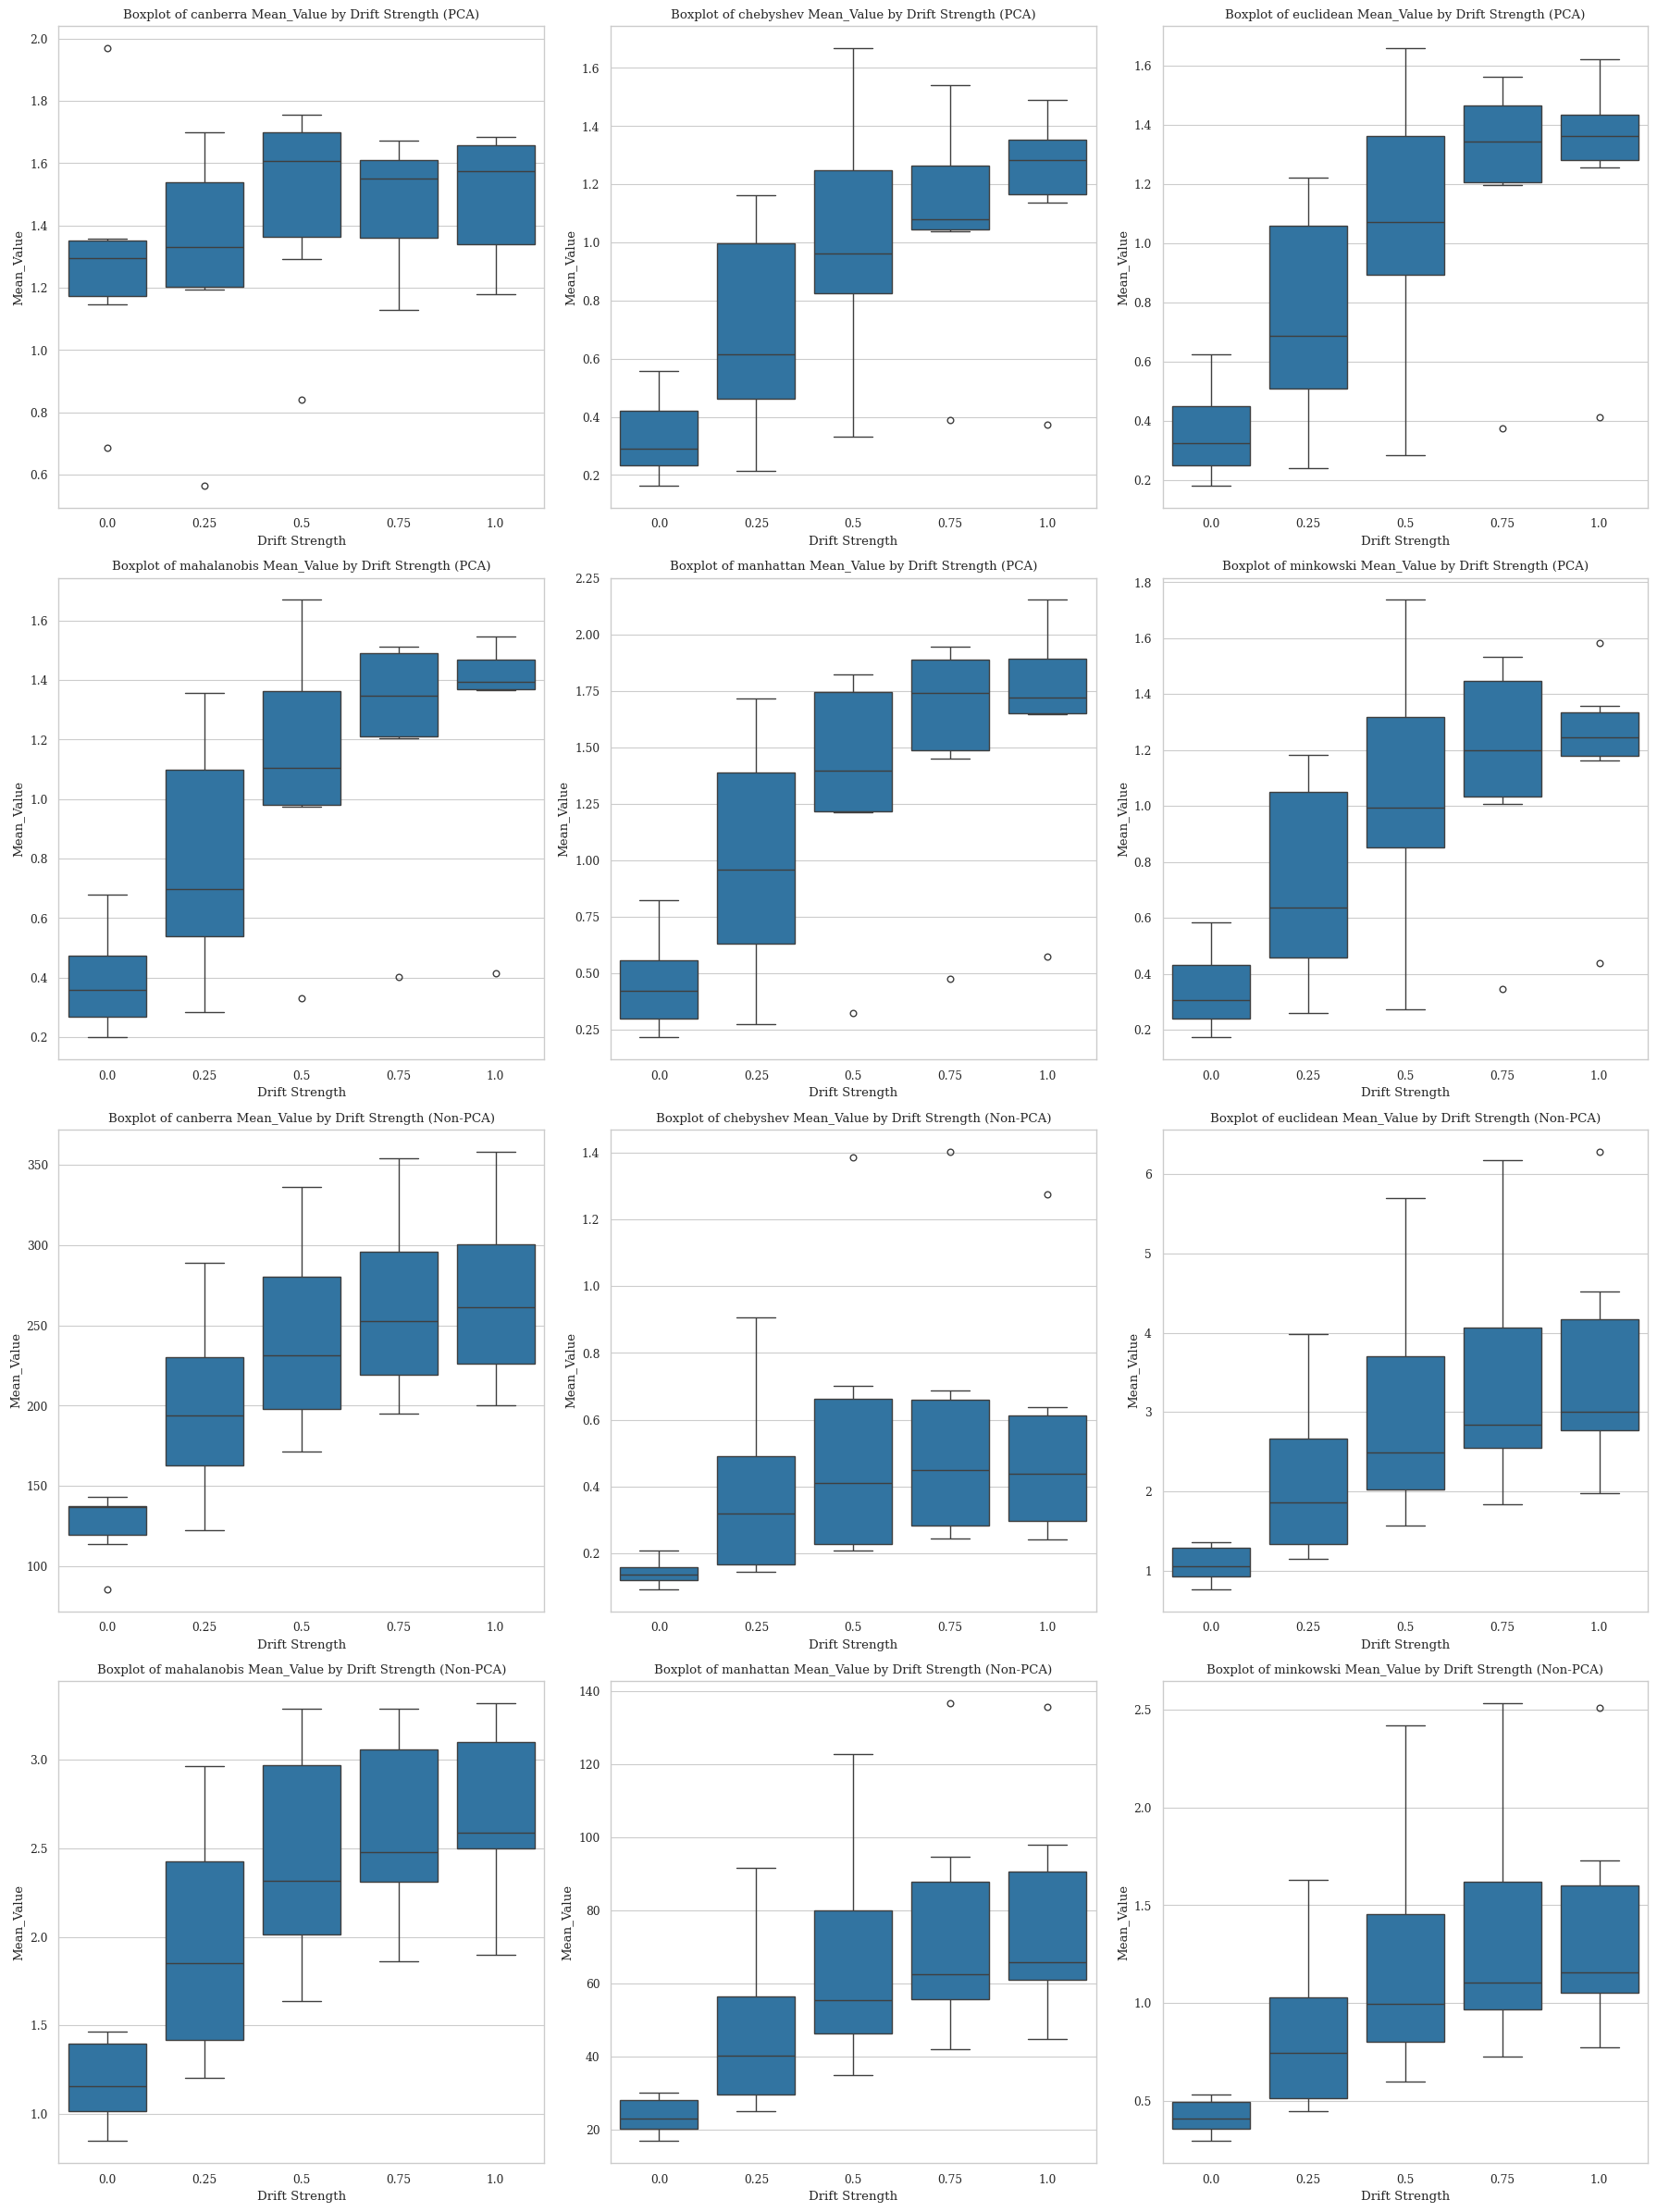

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Rename columns for consistency with the script
df_distance.rename(columns={
    "distance_name": "Measure",
    "drift_strength": "Drift Strength",
    "final_similarity": "Mean_Value",
    "seed": "Seed"
}, inplace=True)

# Include PCA as a separate grouping factor
df_grouped_pca = df_distance.groupby(["Measure", "Dataset", "Model", "Drift Strength", "pca"]).agg(
    Mean_Value=("Mean_Value", "mean"),
    Std_Value=("Mean_Value", "std")
).reset_index()

# Sort the DataFrame
df_sorted_pca = df_grouped_pca.sort_values(by=["Measure", "Dataset", "Model", "Drift Strength", "pca"])

# Compute the relative increase for each measurement
df_sorted_pca["Relative Increase"] = df_sorted_pca.groupby(["Measure", "Dataset", "Model", "pca"])["Mean_Value"].pct_change()
df_sorted_pca.loc[:, "Relative Increase"] = df_sorted_pca["Relative Increase"].fillna(0)

# Compute the standard deviation per measurement
std_per_measurement_pca = df_sorted_pca.groupby(["Measure", "pca"])["Std_Value"].mean()

# Compute the relative increase per measurement (average across datasets/models)
relative_increase_per_measurement_pca = df_sorted_pca.groupby(["Measure", "pca"])["Relative Increase"].mean()

# Combine results
results_pca = pd.DataFrame({
    "Relative Increase": relative_increase_per_measurement_pca,
    "STD": std_per_measurement_pca
}).reset_index()

# Apply log transformation to Relative Increase and STD
log_transformed_pca = np.log1p(results_pca[["Relative Increase", "STD"]])

# Apply Min-Max scaling
min_max_scaler = MinMaxScaler()
scaled_log_values_pca = min_max_scaler.fit_transform(log_transformed_pca)

# Create a new DataFrame with the transformed values
scaled_log_results_pca = results_pca.copy()
scaled_log_results_pca[["Log-Scaled Relative Increase", "Log-Scaled STD"]] = scaled_log_values_pca

# Order the dataframe by Log-Scaled Relative Increase in descending order
ordered_scaled_log_results_pca = scaled_log_results_pca.sort_values(by="Log-Scaled Relative Increase", ascending=False)

# Display the final results
ordered_scaled_log_results_pca = ordered_scaled_log_results_pca.drop(columns=["STD", "Relative Increase"])


# Plotting boxplots for all measures in subplots
unique_measures = df_sorted_pca["Measure"].unique()
n_measures = len(unique_measures)
n_cols = 3
n_rows = 4
fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 24))
axs = axs.flatten()

for i, measure in enumerate(unique_measures):
    measure_data_pca = df_sorted_pca[(df_sorted_pca["Measure"] == measure) & (df_sorted_pca["pca"] == True)]
    measure_data_non_pca = df_sorted_pca[(df_sorted_pca["Measure"] == measure) & (df_sorted_pca["pca"] == False)]

    sns.boxplot(x="Drift Strength", y="Mean_Value", data=measure_data_pca, ax=axs[i])
    axs[i].set_title(f"Boxplot of {measure} Mean_Value by Drift Strength (PCA)")

    sns.boxplot(x="Drift Strength", y="Mean_Value", data=measure_data_non_pca, ax=axs[i + n_measures])
    axs[i + n_measures].set_title(f"Boxplot of {measure} Mean_Value by Drift Strength (Non-PCA)")

# Hide any unused subplots
for j in range(2 * n_measures, n_rows * n_cols):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.savefig("data-analysis/data-test/df_distance_boxplot.png")
plt.show()

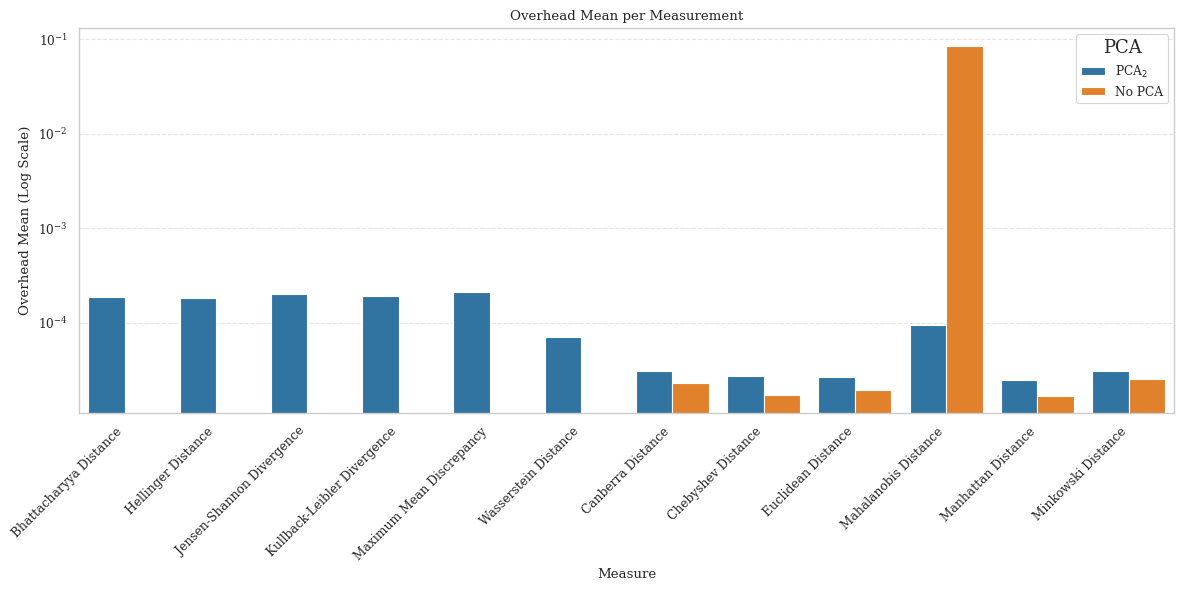

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the datasets
df_distribution = pd.read_csv('data-analysis/data-test/average_overhead_distribution.csv')
df_distance = pd.read_csv('data-analysis/data-test/summary_overhead_vector-distance.csv')

# Rename the column
df_distance.rename(columns={'distance_name': 'measure'}, inplace=True)

# Ensure 'pca' column exists in both dataframes with proper mathematical notation
df_distribution['pca'] = "PCA$_{2}$"
df_distance['pca'] = df_distance['pca'].replace({True: "PCA$_{2}$", False: "No PCA"})

# Concatenate the datasets
merged_df = pd.concat([df_distribution, df_distance], ignore_index=True)

# Map measure names to more descriptive labels
measure_labels = {
    "bhattacharyya": "Bhattacharyya Distance",
    "hellinger": "Hellinger Distance",
    "js": "Jensen-Shannon Divergence",
    "kl": "Kullback-Leibler Divergence",
    "mmd": "Maximum Mean Discrepancy",
    "wasserstein": "Wasserstein Distance",
    "canberra": "Canberra Distance",
    "chebyshev": "Chebyshev Distance",
    "euclidean": "Euclidean Distance",
    "mahalanobis": "Mahalanobis Distance",
    "manhattan": "Manhattan Distance",
    "minkowski": "Minkowski Distance"
}
merged_df['measure'] = merged_df['measure'].map(measure_labels)

# Create a bar plot with PCA next to each other
plt.figure(figsize=(12, 6))
sns.barplot(data=merged_df, x='measure', y='overhead_mean', hue='pca', errorbar='sd', dodge=True)
plt.yscale("log")  # Apply log scale
plt.xticks(rotation=45, ha='right')
plt.title("Overhead Mean per Measurement")
plt.xlabel("Measure")
plt.ylabel("Overhead Mean (Log Scale)")
plt.legend(title="PCA", title_fontsize='13')
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("data-analysis/data-test/overhead_measurement.png")
plt.show()
